In [ ]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense, Conv2D, Flatten, AveragePooling2D
from keras import Sequential
from keras.datasets import mnist

In [ ]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

import numpy as np

# Reshape X_train and X_test to (num_samples, 28, 28, 1) and normalize
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Pad images from 28x28 to 32x32
# Padding with zeros on all sides: (top, bottom, left, right) for (height, width)
# (32-28)/2 = 2 pixels of padding on each side
X_train = np.pad(X_train, ((0,0),(2,2),(2,2),(0,0)), 'constant')
X_test = np.pad(X_test, ((0,0),(2,2),(2,2),(0,0)), 'constant')

print("X_train shape after preprocessing:", X_train.shape)
print("X_test shape after preprocessing:", X_test.shape)

X_train shape after preprocessing: (60000, 32, 32, 1)
X_test shape after preprocessing: (10000, 32, 32, 1)


In [ ]:
model = Sequential()

model.add(Conv2D(6,kernel_size=(5,5),padding='valid', activation='tanh', input_shape=(32,32,1)))
model.add(AveragePooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(16,kernel_size=(5,5),padding='valid', activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
model.fit(X_train,y_train,epochs=10, validation_data=(X_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9666 - loss: 0.1097 - val_accuracy: 0.9781 - val_loss: 0.0709
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 22ms/step - accuracy: 0.9805 - loss: 0.0647 - val_accuracy: 0.9843 - val_loss: 0.0518
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.9856 - loss: 0.0470 - val_accuracy: 0.9829 - val_loss: 0.0474
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9890 - loss: 0.0358 - val_accuracy: 0.9861 - val_loss: 0.0449
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9909 - loss: 0.0274 - val_accuracy: 0.9848 - val_loss: 0.0481
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.9930 - loss: 0.0234 - val_accuracy: 0.9860 - val_loss: 0.0426
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9939 - loss: 0.0189 - val_accuracy: 0.9862 - val_loss: 0.0496
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9943 -

In [ ]:
model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


array([[1.01522085e-06, 9.96904816e-08, 1.26898085e-05, ...,
        9.99535859e-01, 1.93837209e-07, 1.79785984e-05],
       [7.05581033e-06, 2.36820386e-04, 9.99752879e-01, ...,
        2.52136747e-08, 1.99062106e-06, 1.40623943e-10],
       [8.33829727e-10, 9.99997318e-01, 3.94890662e-08, ...,
        1.37216932e-06, 2.38568596e-08, 1.21621699e-10],
       ...,
       [1.68573246e-11, 5.60887443e-08, 7.54032481e-09, ...,
        5.09225458e-07, 3.95809792e-07, 3.89648079e-07],
       [7.11368244e-08, 4.16544736e-08, 7.53111046e-11, ...,
        1.88650184e-09, 3.08864488e-04, 2.08808748e-09],
       [1.00898090e-08, 2.27956622e-08, 3.33253887e-08, ...,
        7.64804539e-11, 1.44592298e-06, 1.42029472e-10]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


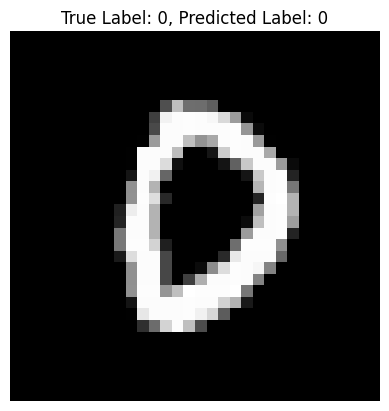

The model predicted: 0
The actual label was: 0


In [ ]:
import matplotlib.pyplot as plt

# Select a random image from the test set
random_index = np.random.randint(0, len(X_test))
sample_image = X_test[random_index]
true_label = y_test[random_index]

# Make a prediction
# The model expects a batch of images, so we add a dimension
prediction = model.predict(sample_image[np.newaxis, ...])
predicted_label = np.argmax(prediction)

# Display the image and results
plt.imshow(sample_image.reshape(32, 32), cmap='gray')
plt.title(f"True Label: {true_label}, Predicted Label: {predicted_label}")
plt.axis('off')
plt.show()

print(f"The model predicted: {predicted_label}")
print(f"The actual label was: {true_label}")